# Data Preparation 

In [1]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Loading the Diabetes dataset
diabetes = load_diabetes()

# Features (X) and target (y)
X = diabetes.data
y = diabetes.target

print("Dataset loaded successfully.\n")

# Checking the dataset's basic structure
print("Number of samples:", X.shape[0])  # Number of data points
print("Number of features:", X.shape[1])  # Number of features

print("\nFeature names:")
print(diabetes.feature_names)  # Feature names

print("\nTarget variable description:")
print(diabetes.DESCR)  # Dataset description

# Converting to DataFrame for easier manipulation
df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y  # Adding target variable

print("\nFirst 5 rows of dataset:")
print(df.head())  # View the first 5 rows

# Checking for missing values
print("\nMissing values in each feature:")
print(df.isnull().sum())  # No missing values expected

# Splitting data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\nTraining set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# Standardizing features to normalize the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Scale training data
X_test_scaled = scaler.transform(X_test)        # Scale testing data

print("\nData standardization completed successfully.")

Dataset loaded successfully.

Number of samples: 442
Number of features: 10

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target variable description:
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    -

# Linear Regression 

Mean Absolute Error (MAE): 52.2600
Mean Squared Error (MSE): 4061.8259
Root Mean Squared Error (RMSE): 63.7325
R-squared (R²): 0.2334


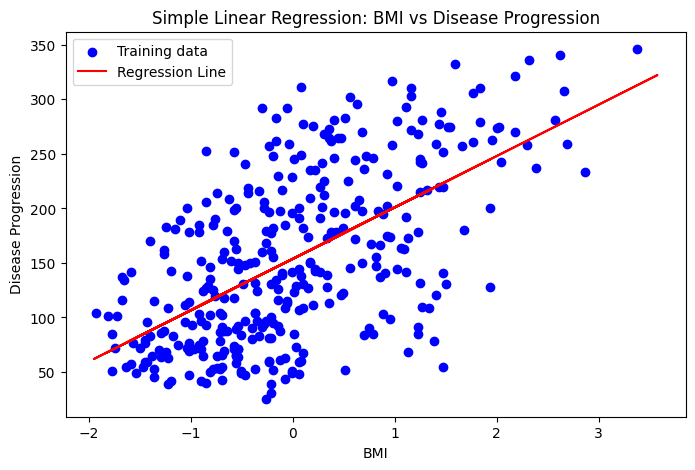

In [2]:
# Step 2: Implementing Simple Linear Regression (using one feature)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Using one feature: bmi (body mass index)
X_bmi = X_train_scaled[:, 2].reshape(-1, 1)  # Selecting the bmi feature

# Trainning the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_bmi, y_train)

# Predicting the target values on the test set
X_bmi_test = X_test_scaled[:, 2].reshape(-1, 1)  # Using bmi feature in test set
y_pred = lin_reg.predict(X_bmi_test)

# Evaluating the model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Printing performance metrics
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# Visualizing the regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_bmi, y_train, color='blue', label='Training data')
plt.plot(X_bmi_test, y_pred, color='red', label='Regression Line')
plt.title('Simple Linear Regression: BMI vs Disease Progression')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()

# Implementing Multiple Regression

Multiple Regression - Mean Absolute Error (MAE): 42.7941
Multiple Regression - Mean Squared Error (MSE): 2900.1936
Multiple Regression - Root Mean Squared Error (RMSE): 53.8534
Multiple Regression - R-squared (R²): 0.4526


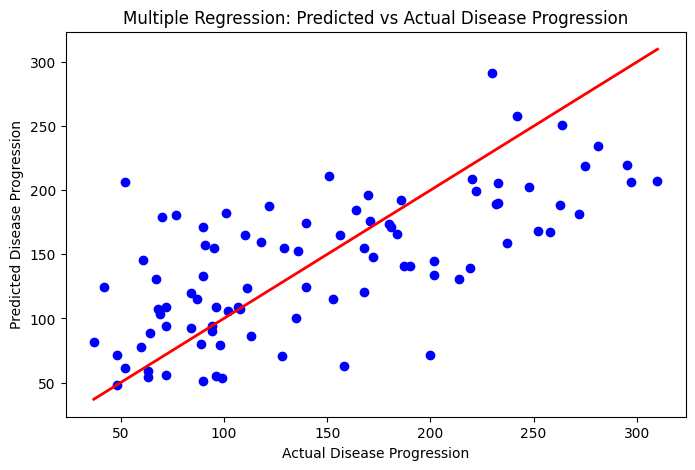

In [3]:
# Step 3: Implementing Multiple Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Using all features except the target variable
X_train_multiple = X_train_scaled  # All features for multiple regression
X_test_multiple = X_test_scaled    # All features for test set

# Creating the Multiple Regression model
multiple_reg_model = LinearRegression()

# Training the model
multiple_reg_model.fit(X_train_multiple, y_train)

# Predicting the target values on the test set
y_pred_multiple = multiple_reg_model.predict(X_test_multiple)

# Evaluating the model performance
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

# Printing performance metrics
print(f"Multiple Regression - Mean Absolute Error (MAE): {mae_multiple:.4f}")
print(f"Multiple Regression - Mean Squared Error (MSE): {mse_multiple:.4f}")
print(f"Multiple Regression - Root Mean Squared Error (RMSE): {rmse_multiple:.4f}")
print(f"Multiple Regression - R-squared (R²): {r2_multiple:.4f}")

# Visualizing the predicted values vs actual values (scatter plot)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_multiple, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # 45-degree line
plt.title('Multiple Regression: Predicted vs Actual Disease Progression')
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.show()

# Implementing Polynomial Regression

Polynomial Regression - Mean Absolute Error (MAE): 43.5817
Polynomial Regression - Mean Squared Error (MSE): 3096.0283
Polynomial Regression - Root Mean Squared Error (RMSE): 55.6420
Polynomial Regression - R-squared (R²): 0.4156


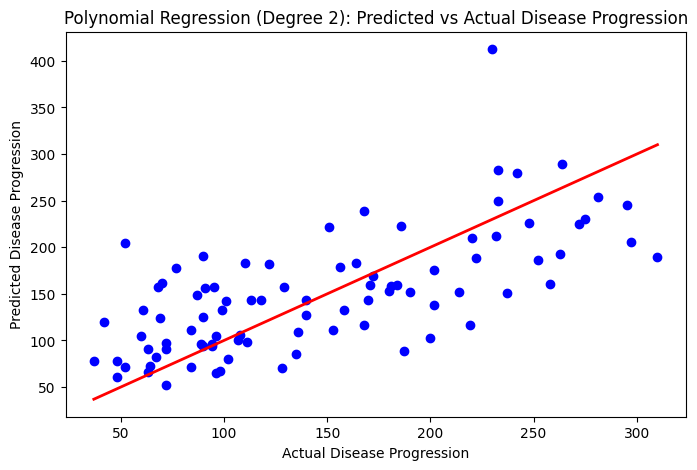

In [4]:
# Step 4: Implementing Polynomial Regression

from sklearn.preprocessing import PolynomialFeatures

# Using all features for polynomial regression
poly_degree = 2  # Polynomial degree (can experiment with higher values like 3)
poly_features = PolynomialFeatures(degree=poly_degree)

# Transforming the features
X_train_poly = poly_features.fit_transform(X_train_scaled)
X_test_poly = poly_features.transform(X_test_scaled)

# Creating and training the polynomial regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train_poly, y_train)

# Predicting the target values
y_pred_poly = poly_reg_model.predict(X_test_poly)

# Evaluating the model performance
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

# Printing performance metrics
print(f"Polynomial Regression - Mean Absolute Error (MAE): {mae_poly:.4f}")
print(f"Polynomial Regression - Mean Squared Error (MSE): {mse_poly:.4f}")
print(f"Polynomial Regression - Root Mean Squared Error (RMSE): {rmse_poly:.4f}")
print(f"Polynomial Regression - R-squared (R²): {r2_poly:.4f}")

# Visualizing the predicted values vs actual values (scatter plot)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_poly, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # 45-degree line
plt.title(f'Polynomial Regression (Degree {poly_degree}): Predicted vs Actual Disease Progression')
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.show()

# Implementing Ridge and Lasso Regression

Ridge Regression (alpha=0.1) - MAE: 42.7962, MSE: 2899.0546, RMSE: 53.8429, R²: 0.4528
Lasso Regression (alpha=0.1) - MAE: 42.8052, MSE: 2884.6243, RMSE: 53.7087, R²: 0.4555


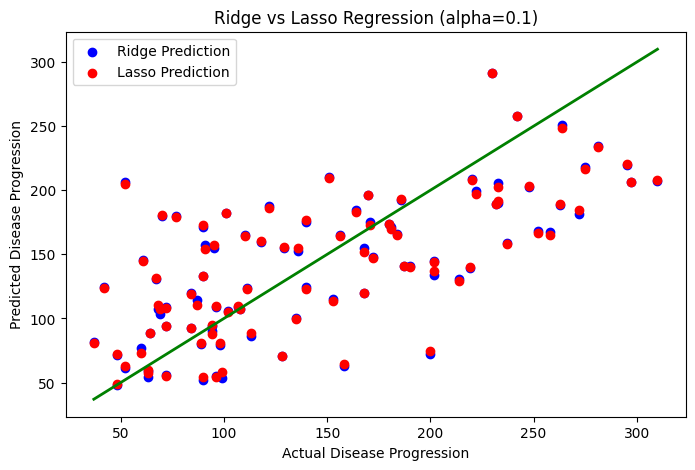

Ridge Regression (alpha=1) - MAE: 42.8120, MSE: 2892.0146, RMSE: 53.7775, R²: 0.4541
Lasso Regression (alpha=1) - MAE: 42.8030, MSE: 2824.5681, RMSE: 53.1467, R²: 0.4669


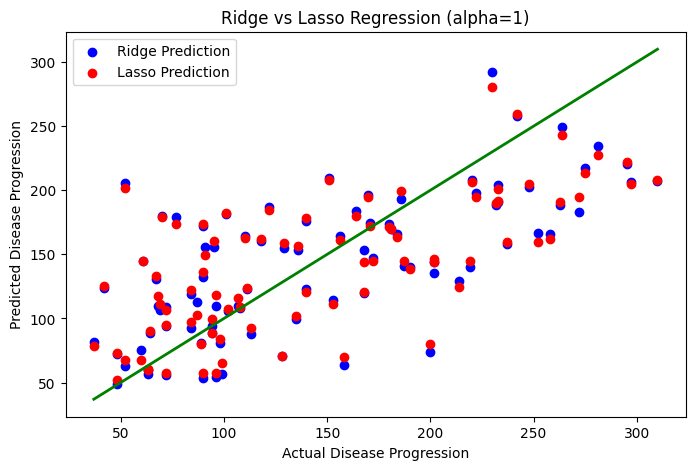

Ridge Regression (alpha=10) - MAE: 42.8568, MSE: 2875.7787, RMSE: 53.6263, R²: 0.4572
Lasso Regression (alpha=10) - MAE: 44.7646, MSE: 2933.8347, RMSE: 54.1649, R²: 0.4463


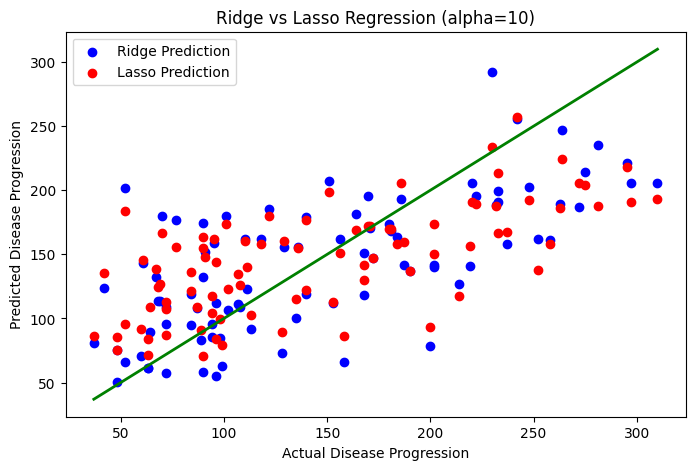

Ridge Regression (alpha=100) - MAE: 43.2507, MSE: 2858.2243, RMSE: 53.4624, R²: 0.4605
Lasso Regression (alpha=100) - MAE: 64.0065, MSE: 5361.5335, RMSE: 73.2225, R²: -0.0120


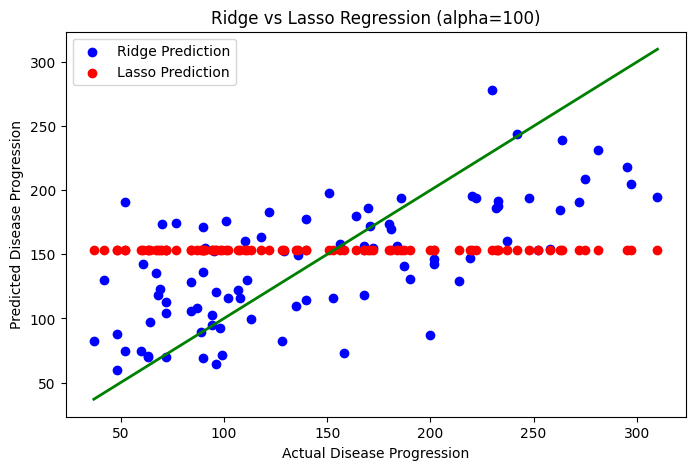

In [6]:
# Step 5: Implementing Ridge and Lasso Regression

from sklearn.linear_model import Ridge, Lasso

# Regularization strength (alpha values) - experiment with these
alpha_values = [0.1, 1, 10, 100]

# Creating Ridge and Lasso models for each alpha
for alpha in alpha_values:
    # Ridge Regression
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    
    # Predicting values for Ridge
    y_pred_ridge = ridge_model.predict(X_test_scaled)
    
    # Evaluate Ridge performance
    mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
    mse_ridge = mean_squared_error(y_test, y_pred_ridge)
    rmse_ridge = np.sqrt(mse_ridge)
    r2_ridge = r2_score(y_test, y_pred_ridge)
    
    # Print Ridge metrics
    print(f"Ridge Regression (alpha={alpha}) - MAE: {mae_ridge:.4f}, MSE: {mse_ridge:.4f}, RMSE: {rmse_ridge:.4f}, R²: {r2_ridge:.4f}")
    
    # Lasso Regression
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train_scaled, y_train)
    
    # Predicting values for Lasso
    y_pred_lasso = lasso_model.predict(X_test_scaled)
    
    # Evaluate Lasso performance
    mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
    mse_lasso = mean_squared_error(y_test, y_pred_lasso)
    rmse_lasso = np.sqrt(mse_lasso)
    r2_lasso = r2_score(y_test, y_pred_lasso)
    
    # Print Lasso metrics
    print(f"Lasso Regression (alpha={alpha}) - MAE: {mae_lasso:.4f}, MSE: {mse_lasso:.4f}, RMSE: {rmse_lasso:.4f}, R²: {r2_lasso:.4f}")
    
    # Visualizing the predicted values vs actual values for both Ridge and Lasso
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, y_pred_ridge, color='blue', label="Ridge Prediction")
    plt.scatter(y_test, y_pred_lasso, color='red', label="Lasso Prediction")
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='green', lw=2)  
    plt.title(f"Ridge vs Lasso Regression (alpha={alpha})")
    plt.xlabel('Actual Disease Progression')
    plt.ylabel('Predicted Disease Progression')
    plt.legend()
    plt.show()

# Model Comparison and Analysis

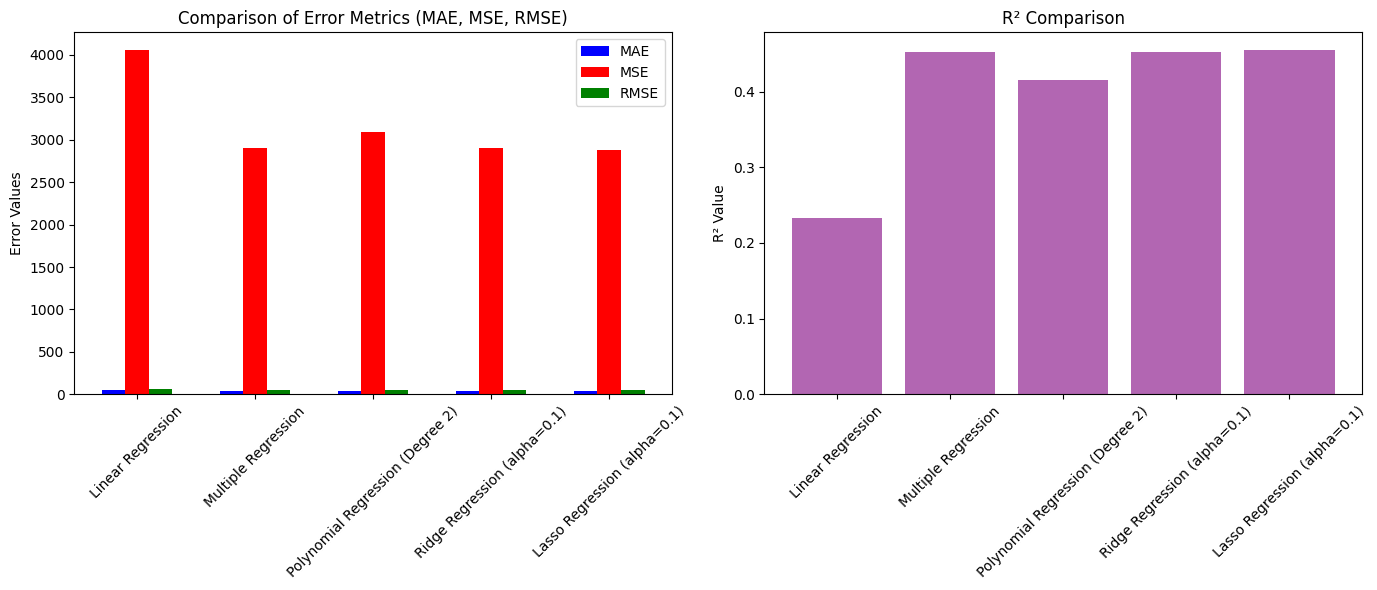

In [8]:

# Plotting side-by-side bars for MAE, MSE, and RMSE
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Set the positions for the bars on the x-axis (side-by-side)
bar_width = 0.2
index = np.arange(len(model_names))

# Plotting MAE, MSE, RMSE
ax[0].bar(index - bar_width, mae_values, bar_width, label="MAE", color="blue")
ax[0].bar(index, mse_values, bar_width, label="MSE", color="red")
ax[0].bar(index + bar_width, rmse_values, bar_width, label="RMSE", color="green")
ax[0].set_title('Comparison of Error Metrics (MAE, MSE, RMSE)')
ax[0].set_ylabel('Error Values')
ax[0].set_xticks(index)
ax[0].set_xticklabels(model_names, rotation=45)
ax[0].legend()

# Plotting R²
ax[1].bar(index, r2_values, label="R²", color="purple", alpha=0.6)
ax[1].set_title('R² Comparison')
ax[1].set_ylabel('R² Value')
ax[1].set_xticks(index)
ax[1].set_xticklabels(model_names, rotation=45)

plt.tight_layout()
plt.show()